# Small illustrative example of NSGA-II for low-CO2 concrete beam design

The purpose of this notebook is to explain, in a simple and transparent way, how a multi-objective optimization procedure can be used to identify concrete beam solutions with low CO2 emissions and acceptable structural performance.

Instead of starting with the full database of beam sections, this notebook uses a very small set of candidate solutions. This makes it possible to inspect every solution manually and understand the logic of the method.

The notebook is structured in four stages:

1. Define a small set of beam solutions  
2. Check which solutions are structurally feasible  
3. Compare the solutions in terms of cost and CO2  
4. Introduce the logic of Pareto optimality and NSGA-II  

This notebook is intended as a teaching example before applying the same ideas to the full design space.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Step 1: Define a very small design space

To explain the optimization procedure clearly, we first create a small number of candidate beam solutions.

Each row in the table represents one beam design alternative.  
For each solution, we include:

- section width  
- section height  
- reinforcement area  
- bending resistance  
- required design moment  
- total CO2 per meter  
- total cost per meter  

The dataset is intentionally very small so that the behaviour of each solution can be followed easily.

In [10]:
import pandas as pd

sectional_capacity = pd.read_pickle("sectional_capacity.pkl")

cols = [
    "Section ID",
    "b [mm]",
    "h [mm]",
    "As [mm2]",
    "M_Rd [kNm]",
    "M_Ed,mid [kNm]",
    "Total CO2 [kg/m]",
    "Total cost [SEK/m]"
]

small_df = sectional_capacity[cols].copy()

small_df = small_df.rename(columns={
    "Section ID": "Solution ID",
    "M_Ed,mid [kNm]": "M_Ed [kNm]"
})

small_df["Feasible"] = small_df["M_Rd [kNm]"] >= small_df["M_Ed [kNm]"]

feasible_pool = small_df[small_df["Feasible"]].copy()
nonfeasible_pool = small_df[~small_df["Feasible"]].copy()

example_df = pd.concat([
    feasible_pool.sample(4, random_state=42),
    nonfeasible_pool.sample(4, random_state=42)
], ignore_index=True)

example_df

,Solution ID,b [mm],h [mm],As [mm2],M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Feasible
0,122,168.0,444.897959,603.185789,104.981056,77.102143,30.472372,183.139412,True
1,272,180.0,444.897959,942.477796,162.875446,77.252296,36.601856,231.099209,True
2,138,209.0,475.510204,804.247719,150.639268,77.795108,40.547176,243.772618,True
3,90,209.0,377.551020,804.247719,116.368468,77.219292,34.405135,213.062414,True
4,139,127.0,481.632653,402.123860,76.450253,76.720332,23.716547,139.101105,False
5,5,168.0,206.122449,603.185789,42.329748,75.973929,18.438086,122.967984,False
6,44,168.0,285.714286,603.185789,63.213517,76.350000,22.449514,143.025127,False
7,106,127.0,414.285714,402.123860,64.669666,76.479777,21.150629,126.271513,False


## Step 2: Check structural feasibility

Before comparing solutions in terms of sustainability and cost, we must first check whether each beam is structurally acceptable.

In this simplified example, a beam is considered feasible if its bending resistance is greater than or equal to the required design moment:

\[
M_{Rd} \geq M_{Ed}
\]

This is a very important step. A beam with very low CO2 is not useful if it cannot carry the applied load.

In [11]:
example_df["Feasible"] = example_df["M_Rd [kNm]"] >= example_df["M_Ed [kNm]"]

example_df[["Solution ID", "M_Rd [kNm]", "M_Ed [kNm]", "Feasible"]]

,Solution ID,M_Rd [kNm],M_Ed [kNm],Feasible
0,122,104.981056,77.102143,True
1,272,162.875446,77.252296,True
2,138,150.639268,77.795108,True
3,90,116.368468,77.219292,True
4,139,76.450253,76.720332,False
5,5,42.329748,75.973929,False
6,44,63.213517,76.350000,False
7,106,64.669666,76.479777,False


## Step 3: Separate feasible and non-feasible solutions

Now that feasibility has been evaluated, we split the design space into two groups:

- feasible solutions  
- non-feasible solutions  

This makes it easier to compare the two groups visually and understand how structural constraints influence the search for better designs.


In [12]:

feasible_df = example_df[example_df["Feasible"]].copy()
nonfeasible_df = example_df[~example_df["Feasible"]].copy()

print("Number of feasible solutions:", len(feasible_df))
print("Number of non-feasible solutions:", len(nonfeasible_df))

Number of feasible solutions: 4
Number of non-feasible solutions: 4


## Step 4: Plot the design space in terms of CO2 and cost

We now represent the candidate beam solutions in the objective space.

The horizontal axis shows total CO2 per meter.  
The vertical axis shows total cost per meter.

This is the same type of plot that is commonly used in multi-objective optimization:
- each point is a design solution
- the lower-left region is desirable because it corresponds to both lower CO2 and lower cost

Feasible and non-feasible solutions are plotted with different colors so that the structural constraint remains visible.

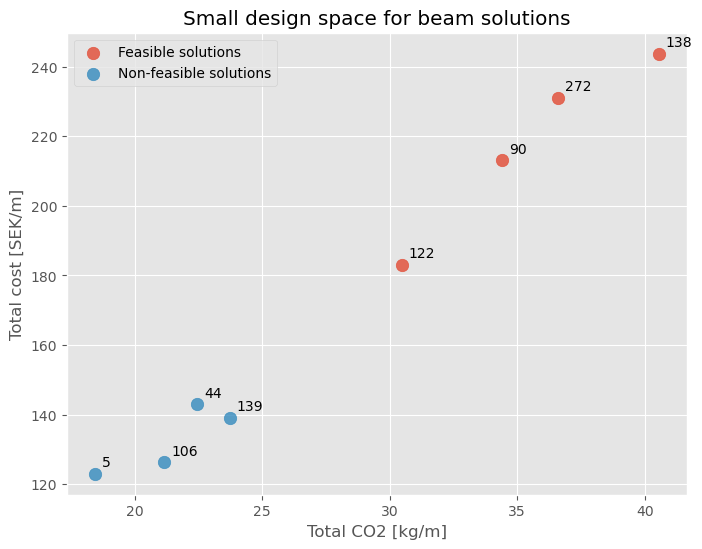

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    feasible_df["Total CO2 [kg/m]"],
    feasible_df["Total cost [SEK/m]"],
    s=80,
    alpha=0.8,
    label="Feasible solutions"
)

plt.scatter(
    nonfeasible_df["Total CO2 [kg/m]"],
    nonfeasible_df["Total cost [SEK/m]"],
    s=80,
    alpha=0.8,
    label="Non-feasible solutions"
)

for _, row in example_df.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Small design space for beam solutions")
plt.legend()
plt.grid(True)
plt.show()

## Step 5: Introduce Pareto optimality

In a multi-objective problem, there is usually no single best solution.

Instead, we look for solutions that are **non-dominated**.

A solution is said to dominate another solution if:
- it is no worse in all objectives
- and strictly better in at least one objective

In this example, the objectives are:
- minimise total CO2
- minimise total cost

The set of non-dominated solutions is called the **Pareto front**.

These solutions represent the best trade-offs currently available in the design space.

## Step 6: Identify Pareto-efficient feasible solutions

We now identify which of the feasible solutions belong to the Pareto front.

For this small example, this can still be done computationally in a very transparent way.  
Later, NSGA-II will use this same idea repeatedly while generating and improving solutions over many generations.

In [14]:
def is_dominated(row, df, obj_cols):
    for _, other in df.iterrows():
        if all(other[col] <= row[col] for col in obj_cols) and any(other[col] < row[col] for col in obj_cols):
            return True
    return False

objective_cols = ["Total CO2 [kg/m]", "Total cost [SEK/m]"]

feasible_df["Dominated"] = feasible_df.apply(
    lambda row: is_dominated(row, feasible_df, objective_cols), axis=1
)

feasible_df["Pareto optimal"] = ~feasible_df["Dominated"]

feasible_df[["Solution ID", "Total CO2 [kg/m]", "Total cost [SEK/m]", "Pareto optimal"]]

,Solution ID,Total CO2 [kg/m],Total cost [SEK/m],Pareto optimal
0,122,30.472372,183.139412,True
1,272,36.601856,231.099209,False
2,138,40.547176,243.772618,False
3,90,34.405135,213.062414,False


## Step 7: Visualise the Pareto-optimal feasible solutions

This plot highlights which feasible solutions are Pareto-optimal.

These are the solutions that NSGA-II would try to preserve and use as promising candidates during the optimization process.

At this stage, we are still not generating new designs.  
We are only learning how to evaluate and rank a small set of existing candidates.

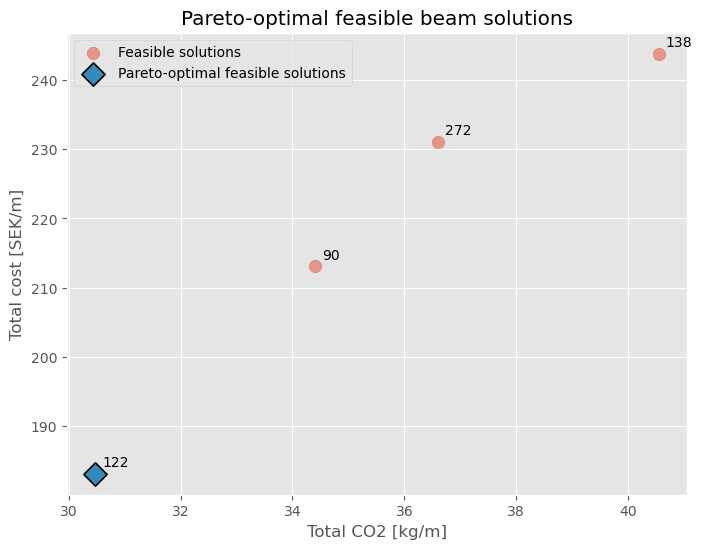

In [15]:
pareto_df = feasible_df[feasible_df["Pareto optimal"]].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    feasible_df["Total CO2 [kg/m]"],
    feasible_df["Total cost [SEK/m]"],
    s=80,
    alpha=0.5,
    label="Feasible solutions"
)

plt.scatter(
    pareto_df["Total CO2 [kg/m]"],
    pareto_df["Total cost [SEK/m]"],
    s=140,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    label="Pareto-optimal feasible solutions"
)

for _, row in feasible_df.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Pareto-optimal feasible beam solutions")
plt.legend()
plt.grid(True)
plt.show()

## Step 8: Connect this small example to NSGA-II

The small example above contains the core ideas behind NSGA-II:

- evaluate candidate solutions  
- reject or penalise non-feasible designs  
- compare solutions using multiple objectives  
- identify non-dominated solutions  
- preserve promising trade-offs  

In a real optimization problem, the number of possible beam designs is far too large to inspect manually.  
For that reason, NSGA-II is used to automate the search process.

In the next stage, the algorithm will:
1. start from an initial population of solutions  
2. rank them by non-domination  
3. preserve diversity among good solutions  
4. generate new candidate designs  
5. repeat the process over many generations  

This allows the search to move gradually toward beam designs with lower CO2 and acceptable structural performance.

## Step 9: Mimic one simple NSGA-II generation

NSGA-II is an evolutionary optimization algorithm.  
This means that it gradually improves a population of candidate solutions over several generations.

To explain the idea clearly, we now perform one simplified generation manually.

In this small example, we will:
- select two parent solutions
- combine their properties to form new child solutions
- apply a small mutation
- evaluate the children in the same way as the original designs

This is not yet a full NSGA-II implementation, but it demonstrates the main logic behind evolutionary optimization.

## Step 10: Select parent solutions

In an evolutionary algorithm, new solutions are created from existing ones.

Here, we select two parent beam designs from the feasible set.  
For teaching purposes, we choose them directly and visibly rather than using a probabilistic selection rule.

Later, in a more complete NSGA-II procedure, parent selection would be based on:
- non-dominated rank
- diversity in the population

In [16]:
parent_1 = feasible_df.iloc[0].copy()
parent_2 = feasible_df.iloc[1].copy()

print("Parent 1")
display(parent_1)

print("Parent 2")
display(parent_2)

Parent 1


Solution ID                  122
b [mm]                     168.0
h [mm]                444.897959
As [mm2]              603.185789
M_Rd [kNm]            104.981056
M_Ed [kNm]             77.102143
Total CO2 [kg/m]       30.472372
Total cost [SEK/m]    183.139412
Feasible                    True
Dominated                  False
Pareto optimal              True
Name: 0, dtype: object

Parent 2


Solution ID                  272
b [mm]                     180.0
h [mm]                444.897959
As [mm2]              942.477796
M_Rd [kNm]            162.875446
M_Ed [kNm]             77.252296
Total CO2 [kg/m]       36.601856
Total cost [SEK/m]    231.099209
Feasible                    True
Dominated                   True
Pareto optimal             False
Name: 1, dtype: object

## Step 11: Create child solutions by crossover

Crossover means that the child solutions inherit properties from both parents.

In this example, we use a very simple crossover rule:
- one child takes the width from one parent and the height from the other
- reinforcement area is also mixed between the parents

This simplified step helps illustrate the principle that new designs can be generated by combining features of previously successful solutions.

In [17]:
children_df = pd.DataFrame({
    "Solution ID": ["Child 1", "Child 2"],
    "b [mm]": [parent_1["b [mm]"], parent_2["b [mm]"]],
    "h [mm]": [parent_2["h [mm]"], parent_1["h [mm]"]],
    "As [mm2]": [parent_2["As [mm2]"], parent_1["As [mm2]"]]
})

children_df

,Solution ID,b [mm],h [mm],As [mm2]
0,Child 1,168.0,444.897959,942.477796
1,Child 2,180.0,444.897959,603.185789


## Step 12: Apply a small mutation

Mutation introduces variation into the population.

Without mutation, the algorithm would only recombine existing designs and could easily become trapped in a small part of the design space.

In this simple example, we apply a small manual mutation by changing one design variable slightly.  
This allows us to demonstrate how a new design can appear that is not identical to either parent.

In [18]:
children_df.loc[0, "h [mm]"] += 20
children_df.loc[1, "b [mm]"] += 20

children_df

,Solution ID,b [mm],h [mm],As [mm2]
0,Child 1,168.0,464.897959,942.477796
1,Child 2,200.0,444.897959,603.185789


## Step 13: Define simple evaluation formulas for the child solutions

The child solutions must now be evaluated in the same way as the original candidate designs.

To keep the example transparent, we use simple approximate formulas:
- bending resistance increases with section size and reinforcement area
- CO2 increases with section size and reinforcement area
- cost also increases with section size and reinforcement area

NOTE: These formulas are not intended to replace the detailed calculations.  
Their purpose is only to illustrate the optimization logic in a compact teaching example.

In [20]:
def evaluate_children(df, design_moment=76):
    df = df.copy()

    # Simple illustrative formulas
    df["M_Rd [kNm]"] = 0.00055 * df["b [mm]"] * df["h [mm]"] + 0.018 * df["As [mm2]"]
    df["M_Ed [kNm]"] = design_moment

    df["Total CO2 [kg/m]"] = (
        0.00018 * df["b [mm]"] * df["h [mm]"] +
        0.0025 * df["As [mm2]"]
    )

    df["Total cost [SEK/m]"] = (
        0.0010 * df["b [mm]"] * df["h [mm]"] +
        0.080 * df["As [mm2]"]
    )

    df["Feasible"] = df["M_Rd [kNm]"] >= df["M_Ed [kNm]"]

    return df

children_df = evaluate_children(children_df)
children_df

,Solution ID,b [mm],h [mm],As [mm2],M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Feasible
0,Child 1,168.0,464.897959,942.477796,59.921172,76,16.414709,153.501081,False
1,Child 2,200.0,444.897959,603.185789,59.796120,76,17.524291,137.234455,False


## Step 14: Compare parents and children in one table

We now collect the selected parent solutions and the new child solutions in one combined table.

This allows us to compare:
- geometry
- reinforcement
- structural resistance
- feasibility
- CO2
- cost

This is the same general idea used in evolutionary optimization:  
an old population and a new population are compared, and the most promising solutions are kept for the next generation.

In [21]:
parents_df = pd.DataFrame([parent_1, parent_2])[[
    "Solution ID", "b [mm]", "h [mm]", "As [mm2]",
    "M_Rd [kNm]", "M_Ed [kNm]", "Total CO2 [kg/m]", "Total cost [SEK/m]", "Feasible"
]].copy()

combined_generation_df = pd.concat([
    parents_df,
    children_df[[
        "Solution ID", "b [mm]", "h [mm]", "As [mm2]",
        "M_Rd [kNm]", "M_Ed [kNm]", "Total CO2 [kg/m]", "Total cost [SEK/m]", "Feasible"
    ]]
], ignore_index=True)

combined_generation_df

,Solution ID,b [mm],h [mm],As [mm2],M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Feasible
0,122,168.0,444.897959,603.185789,104.981056,77.102143,30.472372,183.139412,True
1,272,180.0,444.897959,942.477796,162.875446,77.252296,36.601856,231.099209,True
2,Child 1,168.0,464.897959,942.477796,59.921172,76.000000,16.414709,153.501081,False
3,Child 2,200.0,444.897959,603.185789,59.796120,76.000000,17.524291,137.234455,False


## Step 15: Plot parents and children in the objective space

This plot shows how the new child solutions compare with the selected parent solutions.

The objective space remains the same:
- horizontal axis: total CO2
- vertical axis: total cost

This helps us see whether the new generation has moved toward more attractive regions of the design space.

In a real NSGA-II procedure, many solutions would be evaluated in each generation, and this improvement process would continue over many iterations.

In [23]:
print(parent_1["Solution ID"])
print(parent_2["Solution ID"])
print(combined_generation_df["Solution ID"].tolist())

122
272
[122, 272, 'Child 1', 'Child 2']


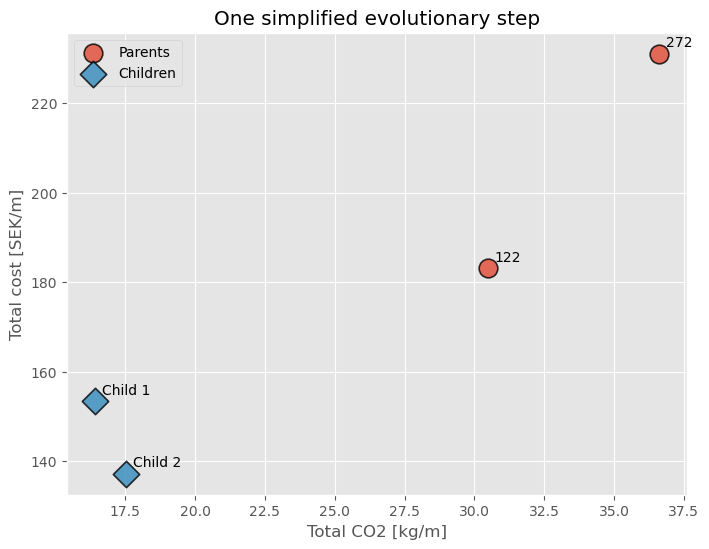

In [24]:
plt.figure(figsize=(8, 6))

parent_ids = [parent_1["Solution ID"], parent_2["Solution ID"]]
child_ids = ["Child 1", "Child 2"]

parent_points = combined_generation_df[combined_generation_df["Solution ID"].isin(parent_ids)]
child_points = combined_generation_df[combined_generation_df["Solution ID"].isin(child_ids)]

plt.scatter(
    parent_points["Total CO2 [kg/m]"],
    parent_points["Total cost [SEK/m]"],
    s=180,
    marker="o",
    edgecolors="black",
    linewidths=1.2,
    alpha=0.8,
    label="Parents"
)

plt.scatter(
    child_points["Total CO2 [kg/m]"],
    child_points["Total cost [SEK/m]"],
    s=180,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    alpha=0.8,
    label="Children"
)

for _, row in combined_generation_df.iterrows():
    plt.annotate(
        str(row["Solution ID"]),
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("One simplified evolutionary step")
plt.legend()
plt.grid(True)
plt.show()

## Step 16: Explain how this connects to NSGA-II

The simplified generation above already contains the most important ingredients of an evolutionary optimization method:

- parent solutions are selected  
- children are created through crossover  
- mutation introduces variation  
- new solutions are evaluated  
- promising solutions can be retained  

NSGA-II extends this idea in a more systematic way.

In the full algorithm:
- many candidate solutions are handled at once
- solutions are ranked by non-domination
- diversity is preserved using crowding distance
- the process is repeated for many generations

The result is a population that moves toward better trade-offs between structural feasibility, low CO2, and low cost.

## Step 17: Rank the combined population using non-dominated sorting

After generating child solutions, we now have a combined population containing both parents and children.

The next task is to determine which solutions are more attractive in a multi-objective sense.

In NSGA-II, this is done by **non-dominated sorting**.

The idea is:
- solutions that are not dominated by any other solution belong to the first Pareto front
- after removing these, the next set of non-dominated solutions forms the second front
- this process continues until all solutions have been ranked

In this teaching example, we use only the first front to illustrate the principle clearly.

## Step 18: Define a simple dominance rule with feasibility

In beam design, structural feasibility must always come before optimization of cost and CO2.

For that reason, we use the following logic:
- a feasible solution is always preferred over a non-feasible solution
- between two feasible solutions, Pareto dominance is checked using CO2 and cost
- between two non-feasible solutions, Pareto dominance can still be checked, but they remain less attractive than feasible ones

This reflects the real design problem: a low-CO2 beam is only interesting if it can actually carry the required load.

In [25]:
objective_cols = ["Total CO2 [kg/m]", "Total cost [SEK/m]"]

def dominates(row_a, row_b, obj_cols):
    # Feasible solutions are always preferred over non-feasible ones
    if row_a["Feasible"] and not row_b["Feasible"]:
        return True
    if not row_a["Feasible"] and row_b["Feasible"]:
        return False

    # If both have same feasibility status, compare objectives
    no_worse = all(row_a[col] <= row_b[col] for col in obj_cols)
    strictly_better = any(row_a[col] < row_b[col] for col in obj_cols)

    return no_worse and strictly_better

## Step 19: Identify the first Pareto front

We now check each solution in the combined population and determine whether it is dominated by any other solution.

If a solution is not dominated by any other solution, it belongs to the first Pareto front.

In NSGA-II, these first-front solutions are especially important because they represent the best currently available trade-offs between the objectives.

In [26]:
def get_first_pareto_front(df, obj_cols):
    front_indices = []

    for i, row_i in df.iterrows():
        dominated_flag = False

        for j, row_j in df.iterrows():
            if i == j:
                continue

            if dominates(row_j, row_i, obj_cols):
                dominated_flag = True
                break

        if not dominated_flag:
            front_indices.append(i)

    return df.loc[front_indices].copy()

first_front_df = get_first_pareto_front(combined_generation_df, objective_cols)
first_front_df

,Solution ID,b [mm],h [mm],As [mm2],M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Feasible
0,122,168.0,444.897959,603.185789,104.981056,77.102143,30.472372,183.139412,True


## Step 20: Visualise the first Pareto front

This figure highlights the solutions in the first Pareto front.

These are the solutions that would be most attractive for survival into the next generation.

Even in this very small example, we can already see an important idea of multi-objective optimization:
there is often not one single best solution, but rather a set of competing trade-off solutions.

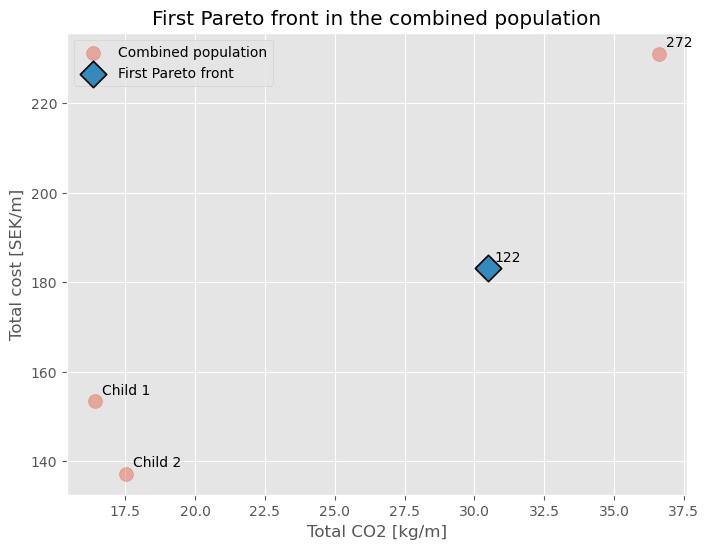

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    combined_generation_df["Total CO2 [kg/m]"],
    combined_generation_df["Total cost [SEK/m]"],
    s=100,
    alpha=0.4,
    label="Combined population"
)

plt.scatter(
    first_front_df["Total CO2 [kg/m]"],
    first_front_df["Total cost [SEK/m]"],
    s=180,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    label="First Pareto front"
)

for _, row in combined_generation_df.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("First Pareto front in the combined population")
plt.legend()
plt.grid(True)
plt.show()

## Step 21: Assign a simple Pareto rank

To prepare for next-generation selection, we now assign a simple rank to each solution.

For this teaching example:
- solutions in the first Pareto front receive rank 1
- all other solutions receive rank 2

In a full NSGA-II implementation, this would continue with rank 3, rank 4, and so on until all solutions are classified.

In [28]:
combined_generation_df = combined_generation_df.copy()
combined_generation_df["Pareto rank"] = 2
combined_generation_df.loc[first_front_df.index, "Pareto rank"] = 1

combined_generation_df[[
    "Solution ID", "Feasible", "Total CO2 [kg/m]", "Total cost [SEK/m]", "Pareto rank"
]]

,Solution ID,Feasible,Total CO2 [kg/m],Total cost [SEK/m],Pareto rank
0,122,True,30.472372,183.139412,1
1,272,True,36.601856,231.099209,2
2,Child 1,False,16.414709,153.501081,2
3,Child 2,False,17.524291,137.234455,2


## Step 22: Select the next generation

The purpose of NSGA-II is not only to generate new solutions, but also to decide which solutions should survive into the next generation.

In this simple example, we choose a small population size and keep the best solutions according to:
1. feasibility  
2. Pareto rank  
3. objective values  

This is still a simplified version of NSGA-II, but it already shows the central idea of survival selection.

In [29]:
next_generation_size = 4

next_generation_df = combined_generation_df.sort_values(
    by=["Feasible", "Pareto rank", "Total CO2 [kg/m]", "Total cost [SEK/m]"],
    ascending=[False, True, True, True]
).head(next_generation_size).copy()

next_generation_df

,Solution ID,b [mm],h [mm],As [mm2],M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Feasible,Pareto rank
0,122,168.0,444.897959,603.185789,104.981056,77.102143,30.472372,183.139412,True,1
1,272,180.0,444.897959,942.477796,162.875446,77.252296,36.601856,231.099209,True,2
2,Child 1,168.0,464.897959,942.477796,59.921172,76.000000,16.414709,153.501081,False,2
3,Child 2,200.0,444.897959,603.185789,59.796120,76.000000,17.524291,137.234455,False,2


## Step 23: Interpret the selected next generation

The table above represents the surviving solutions after one simplified generation.

These are the beam designs that would be used as the basis for the next round of optimization.

This reflects the main evolutionary idea:
- weaker solutions disappear
- stronger solutions survive
- new solutions are generated from the survivors

By repeating this procedure many times, the population can gradually move toward better and better feasible low-CO2 solutions.

## Step 24: Plot the selected next generation

This final plot highlights the solutions that survive into the next generation.

The aim is to make the selection process easy to understand visually:
- the full combined population is shown in the background
- the selected survivors are highlighted

This closes one complete simplified optimization cycle:
- evaluate
- rank
- generate children
- compare populations
- keep the best solutions

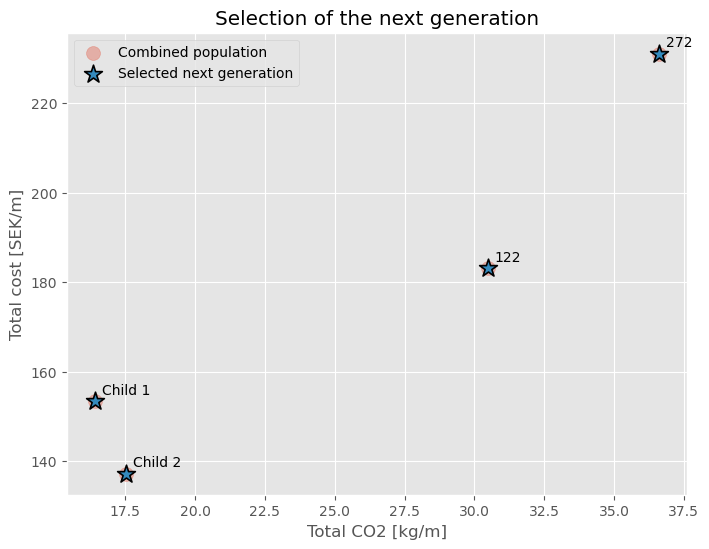

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    combined_generation_df["Total CO2 [kg/m]"],
    combined_generation_df["Total cost [SEK/m]"],
    s=100,
    alpha=0.35,
    label="Combined population"
)

plt.scatter(
    next_generation_df["Total CO2 [kg/m]"],
    next_generation_df["Total cost [SEK/m]"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    label="Selected next generation"
)

for _, row in combined_generation_df.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Selection of the next generation")
plt.legend()
plt.grid(True)
plt.show()

## Step 25: Summary of the simplified NSGA-II logic

At this point, the notebook has demonstrated the main ideas behind NSGA-II in a small and transparent way.

The procedure can now be summarized as follows:

1. Define candidate beam solutions  
2. Check structural feasibility  
3. Evaluate cost and CO2  
4. Identify non-dominated solutions  
5. Generate child solutions from good parents  
6. Combine old and new populations  
7. Select the best solutions for the next generation  

In the full NSGA-II algorithm, this process is repeated automatically for many generations, and diversity between solutions is also preserved using the crowding-distance concept.

This small example is therefore a useful bridge between manual engineering comparison and full multi-objective evolutionary optimization.

## Step 26: Move from one generation to an iterative optimization loop

So far, the notebook has shown one simplified evolutionary step.

However, the main strength of NSGA-II is that the same logic is repeated over many generations.  
This allows the search process to gradually move toward better trade-offs between structural feasibility, low CO2, and low cost.

In this section, we implement a small iterative loop that:
- starts from an initial population
- evaluates all solutions
- selects promising designs
- generates children
- repeats the procedure for several generations

The purpose is not yet to create a full advanced NSGA-II solver, but rather to demonstrate the core iterative mechanism in a clear way.

## Step 26: Move from one generation to an iterative optimization loop

So far, the notebook has shown one simplified evolutionary step.

However, the main strength of NSGA-II is that the same logic is repeated over many generations.  
This allows the search process to gradually move toward better trade-offs between structural feasibility, low CO2, and low cost.

In this section, we implement a small iterative loop that:
- starts from an initial population
- evaluates all solutions
- selects promising designs
- generates children
- repeats the procedure for several generations

The purpose is not yet to create a full advanced NSGA-II solver, but rather to demonstrate the core iterative mechanism in a clear way.

In [33]:
import pandas as pd
import numpy as np

objective_cols = ["Total CO2 [kg/m]", "Total cost [SEK/m]"]

# ------------------------------------------------------------
# Build lookup table from the real dataset
# ------------------------------------------------------------
real_df = sectional_capacity.copy()

real_df = real_df[[
    "Section ID",
    "b [mm]",
    "h [mm]",
    "As [mm2]",
    "M_Rd [kNm]",
    "M_Ed,mid [kNm]",
    "Total CO2 [kg/m]",
    "Total cost [SEK/m]"
]].copy()

# If several rows have the same b, h, As combination,
# keep the one with the lowest CO2
real_df = real_df.sort_values("Total CO2 [kg/m]").drop_duplicates(
    subset=["b [mm]", "h [mm]", "As [mm2]"],
    keep="first"
).reset_index(drop=True)

# Allowed discrete values from the real design space
allowed_b = np.sort(real_df["b [mm]"].unique())
allowed_h = np.sort(real_df["h [mm]"].unique())
allowed_As = np.sort(real_df["As [mm2]"].unique())

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def evaluate_population(df):
    df = df.copy()

    evaluated = df.merge(
        real_df,
        on=["b [mm]", "h [mm]", "As [mm2]"],
        how="left"
    )

    # Keep candidate Solution ID rather than the matched Section ID
    if "Solution ID_x" in evaluated.columns:
        evaluated["Solution ID"] = evaluated["Solution ID_x"]
        evaluated = evaluated.drop(columns=["Solution ID_x"])

    if "Solution ID_y" in evaluated.columns:
        evaluated = evaluated.drop(columns=["Solution ID_y"])

    # Rename demand column for cleaner use in the optimization notebook
    evaluated = evaluated.rename(columns={
        "M_Ed,mid [kNm]": "M_Ed [kNm]"
    })

    # Mark whether the child actually matches a real section
    evaluated["Matched real section"] = evaluated["M_Rd [kNm]"].notna()

    # Feasibility only if the section exists and satisfies bending demand
    evaluated["Feasible"] = (
        evaluated["Matched real section"] &
        (evaluated["M_Rd [kNm]"] >= evaluated["M_Ed [kNm]"])
    )

    return evaluated


def dominates(row_a, row_b, obj_cols):
    # Feasible solutions are always preferred over non-feasible solutions
    if row_a["Feasible"] and not row_b["Feasible"]:
        return True
    if not row_a["Feasible"] and row_b["Feasible"]:
        return False

    # If one row has missing objective values, do not allow dominance
    if pd.isna(row_a[obj_cols]).any() or pd.isna(row_b[obj_cols]).any():
        return False

    no_worse = all(row_a[col] <= row_b[col] for col in obj_cols)
    strictly_better = any(row_a[col] < row_b[col] for col in obj_cols)

    return no_worse and strictly_better


def get_first_pareto_front(df, obj_cols):
    front_indices = []

    for i, row_i in df.iterrows():
        dominated_flag = False

        for j, row_j in df.iterrows():
            if i == j:
                continue

            if dominates(row_j, row_i, obj_cols):
                dominated_flag = True
                break

        if not dominated_flag:
            front_indices.append(i)

    return df.loc[front_indices].copy()


def mutate_to_allowed(current_value, allowed_values):
    allowed_values = np.array(sorted(allowed_values))
    idx = np.where(allowed_values == current_value)[0]

    # If exact value is not found, snap to nearest allowed value
    if len(idx) == 0:
        nearest_idx = np.argmin(np.abs(allowed_values - current_value))
        idx = nearest_idx
    else:
        idx = idx[0]

    # Mutation options: stay, move one step down, move one step up
    candidate_indices = [idx]
    if idx > 0:
        candidate_indices.append(idx - 1)
    if idx < len(allowed_values) - 1:
        candidate_indices.append(idx + 1)

    new_idx = np.random.choice(candidate_indices)
    return allowed_values[new_idx]


def make_child(parent_1, parent_2, child_name):
    child = {}
    child["Solution ID"] = child_name

    # Simple crossover from parents
    child["b [mm]"] = np.random.choice([parent_1["b [mm]"], parent_2["b [mm]"]])
    child["h [mm]"] = np.random.choice([parent_1["h [mm]"], parent_2["h [mm]"]])
    child["As [mm2]"] = np.random.choice([parent_1["As [mm2]"], parent_2["As [mm2]"]])

    # Mutation using only allowed real values
    if np.random.rand() < 0.5:
        child["b [mm]"] = mutate_to_allowed(child["b [mm]"], allowed_b)

    if np.random.rand() < 0.5:
        child["h [mm]"] = mutate_to_allowed(child["h [mm]"], allowed_h)

    if np.random.rand() < 0.5:
        child["As [mm2]"] = mutate_to_allowed(child["As [mm2]"], allowed_As)

    return child


# ------------------------------------------------------------
# Optional quick check
# ------------------------------------------------------------
print("Number of real unique design combinations:", len(real_df))
print("Allowed b values:", allowed_b)
print("Allowed h values:", allowed_h[:10], "..." if len(allowed_h) > 10 else "")
print("Allowed As values:", allowed_As[:10], "..." if len(allowed_As) > 10 else "")

Number of real unique design combinations: 450
Allowed b values: [127. 135. 145. 168. 180. 195. 209. 225. 245.]
Allowed h values: [200.         206.12244898 212.24489796 218.36734694 224.48979592
 230.6122449  236.73469388 242.85714286 248.97959184 255.10204082] ...
Allowed As values: [ 402.12385966  603.18578949  628.31853072  804.24771932  942.47779608
  981.74770425 1256.63706144 1472.62155637 1963.49540849] 


## Step 28: Define the initial population

We now define the starting population for the iterative search.

For this teaching example, the initial population is simply the small set of candidate beam solutions introduced earlier.

In a more advanced implementation, the initial population could be generated randomly within specified design-variable bounds.

In [34]:
population_df = example_df[["Solution ID", "b [mm]", "h [mm]", "As [mm2]"]].copy()
population_df = evaluate_population(population_df)
population_df

,Solution ID,b [mm],h [mm],As [mm2],Section ID,M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Matched real section,Feasible
0,122,168.0,444.897959,603.185789,122,104.981056,77.102143,30.472372,183.139412,True,True
1,272,180.0,444.897959,942.477796,272,162.875446,77.252296,36.601856,231.099209,True,True
2,138,209.0,475.510204,804.247719,138,150.639268,77.795108,40.547176,243.772618,True,True
3,90,209.0,377.551020,804.247719,90,116.368468,77.219292,34.405135,213.062414,True,True
4,139,127.0,481.632653,402.123860,139,76.450253,76.720332,23.716547,139.101105,True,False
5,5,168.0,206.122449,603.185789,5,42.329748,75.973929,18.438086,122.967984,True,False
6,44,168.0,285.714286,603.185789,44,63.213517,76.350000,22.449514,143.025127,True,False
7,106,127.0,414.285714,402.123860,106,64.669666,76.479777,21.150629,126.271513,True,False


## Step 29: Run the simplified evolutionary loop

The loop below performs several generations of evolutionary search.

In each generation, it does the following:
1. evaluate the current population  
2. identify the first Pareto front  
3. select parent solutions  
4. create children through crossover and mutation  
5. combine parents and children  
6. keep the best solutions for the next generation  

This repeats the same core logic that was previously shown for just one generation, but now in an automated way.

In [36]:
np.random.seed(42)

population_size = 8
n_generations = 10

history = []

design_cols = ["Solution ID", "b [mm]", "h [mm]", "As [mm2]"]

current_population = population_df[design_cols].copy()

for generation in range(n_generations):
    # Re-evaluate only from design variables
    current_population = evaluate_population(current_population[design_cols].copy())

    first_front = get_first_pareto_front(current_population, objective_cols).copy()
    first_front["Generation"] = generation + 1
    history.append(first_front)

    # Parent pool: prefer feasible solutions in first front
    feasible_front = first_front[first_front["Feasible"]].copy()

    if len(feasible_front) >= 2:
        parent_pool = feasible_front
    elif len(first_front) >= 2:
        parent_pool = first_front
    else:
        parent_pool = current_population.copy()

    # Create children
    children = []
    for child_idx in range(population_size):
        parents = parent_pool.sample(2, replace=True)
        parent_1 = parents.iloc[0]
        parent_2 = parents.iloc[1]

        child = make_child(parent_1, parent_2, f"G{generation+1}_C{child_idx+1}")
        children.append(child)

    children_df = pd.DataFrame(children)
    children_df = evaluate_population(children_df)

    # Combine current population and children
    combined_df = pd.concat([current_population, children_df], ignore_index=True)

    # Optional: remove exact duplicate designs
    combined_df = combined_df.drop_duplicates(
        subset=["b [mm]", "h [mm]", "As [mm2]"],
        keep="first"
    ).reset_index(drop=True)

    # Rank using only first front vs others
    combined_df["Pareto rank"] = 2
    combined_first_front = get_first_pareto_front(combined_df, objective_cols)
    combined_df.loc[combined_first_front.index, "Pareto rank"] = 1

    # Select next generation
    current_population = combined_df.sort_values(
        by=["Feasible", "Pareto rank", "Total CO2 [kg/m]", "Total cost [SEK/m]"],
        ascending=[False, True, True, True]
    ).head(population_size).copy()

    # Keep only design vars for the next iteration
    current_population = current_population[design_cols]

# Final evaluated population
current_population = evaluate_population(current_population)
current_population

,Solution ID,b [mm],h [mm],As [mm2],Section ID,M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Matched real section,Feasible
0,G9_C3,168.0,395.918367,603.185789,98,92.129505,76.870714,28.003800,170.796555,True,True
1,G8_C7,168.0,402.040816,603.185789,101,93.735949,76.899643,28.312372,172.339412,True,True
2,G6_C1,168.0,408.163265,603.185789,104,95.342393,76.928571,28.620943,173.882270,True,True
3,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True
4,122,168.0,444.897959,603.185789,122,104.981056,77.102143,30.472372,183.139412,True,True
5,G7_C7,168.0,451.020408,603.185789,125,106.587499,77.131071,30.780943,184.682270,True,True
6,G8_C3,168.0,457.142857,603.185789,128,108.193943,77.160000,31.089514,186.225127,True,True
7,G4_C3,180.0,383.673469,942.477796,242,137.774762,76.942347,33.295734,214.568597,True,True


## Step 30: Collect the Pareto-front history over all generations

To understand how the optimization develops over time, it is useful to store the Pareto front from each generation.

This makes it possible to observe whether the population is gradually moving toward lower CO2 and lower cost while maintaining structural feasibility.

In [37]:
history_df = pd.concat(history, ignore_index=True)
history_df

,Solution ID,b [mm],h [mm],As [mm2],Section ID,M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Matched real section,Feasible,Generation
0,122,168.0,444.897959,603.185789,122,104.981056,77.102143,30.472372,183.139412,True,True,1
1,122,168.0,444.897959,603.185789,122,104.981056,77.102143,30.472372,183.139412,True,True,2
2,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True,3
3,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True,4
4,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True,5
5,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True,6
6,G6_C1,168.0,408.163265,603.185789,104,95.342393,76.928571,28.620943,173.882270,True,True,7
7,G6_C1,168.0,408.163265,603.185789,104,95.342393,76.928571,28.620943,173.882270,True,True,8
8,G8_C7,168.0,402.040816,603.185789,101,93.735949,76.899643,28.312372,172.339412,True,True,9
9,G9_C3,168.0,395.918367,603.185789,98,92.129505,76.870714,28.003800,170.796555,True,True,10


## Step 31: Plot the Pareto-front solutions from all generations

This figure shows the Pareto-front solutions that appeared during the iterative search.

Each point represents a solution that belonged to the first Pareto front in at least one generation.

This helps us see how the optimization process explores the design space over time.

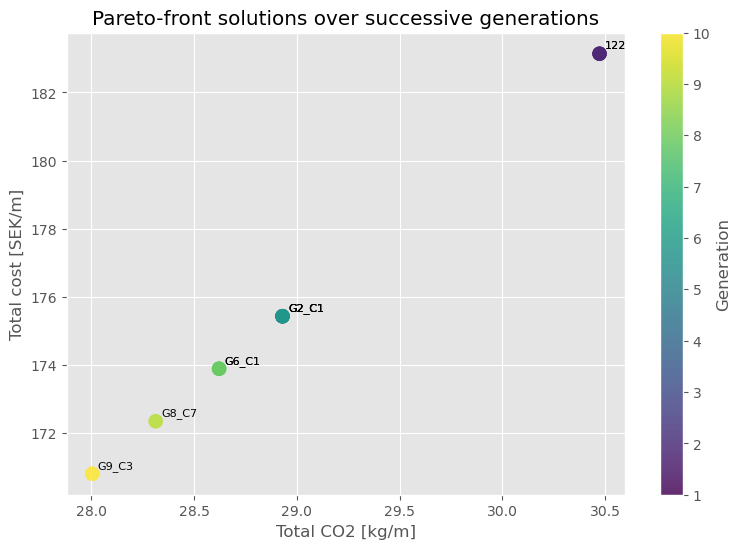

In [38]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    history_df["Total CO2 [kg/m]"],
    history_df["Total cost [SEK/m]"],
    c=history_df["Generation"],
    s=100,
    alpha=0.8
)

for _, row in history_df.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Pareto-front solutions over successive generations")
plt.grid(True)
plt.colorbar(scatter, label="Generation")
plt.show()

## Step 32: Show the final population

After the loop ends, the final population represents the surviving solutions after several rounds of selection, crossover, mutation, and survival.

These solutions are not guaranteed to be globally optimal, but they illustrate the main purpose of NSGA-II:
to move the search toward better feasible trade-offs between competing objectives.

In [39]:
final_population = current_population.copy()
final_population

,Solution ID,b [mm],h [mm],As [mm2],Section ID,M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Matched real section,Feasible
0,G9_C3,168.0,395.918367,603.185789,98,92.129505,76.870714,28.003800,170.796555,True,True
1,G8_C7,168.0,402.040816,603.185789,101,93.735949,76.899643,28.312372,172.339412,True,True
2,G6_C1,168.0,408.163265,603.185789,104,95.342393,76.928571,28.620943,173.882270,True,True
3,G2_C1,168.0,414.285714,603.185789,107,96.948837,76.957500,28.929514,175.425127,True,True
4,122,168.0,444.897959,603.185789,122,104.981056,77.102143,30.472372,183.139412,True,True
5,G7_C7,168.0,451.020408,603.185789,125,106.587499,77.131071,30.780943,184.682270,True,True
6,G8_C3,168.0,457.142857,603.185789,128,108.193943,77.160000,31.089514,186.225127,True,True
7,G4_C3,180.0,383.673469,942.477796,242,137.774762,76.942347,33.295734,214.568597,True,True


## Step 33: Highlight the final feasible Pareto front

The final step is to identify the Pareto-efficient feasible solutions in the last generation.

These are the solutions that represent the best trade-offs found by the simplified iterative search.

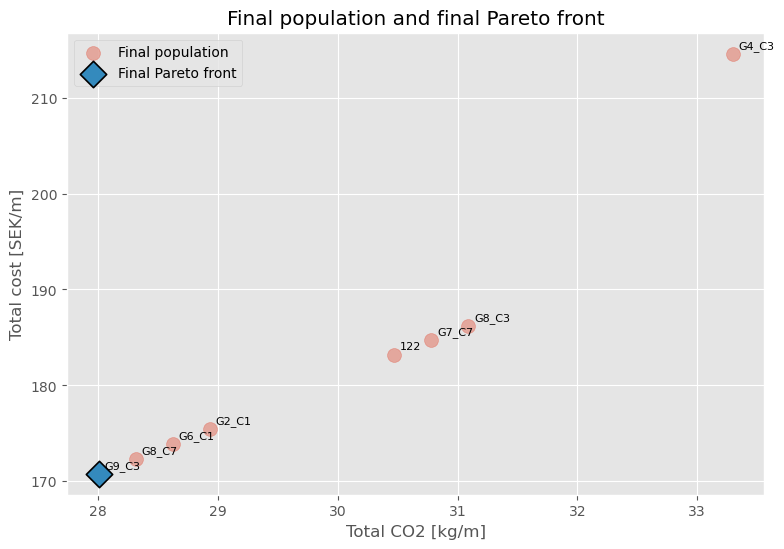

,Solution ID,b [mm],h [mm],As [mm2],Section ID,M_Rd [kNm],M_Ed [kNm],Total CO2 [kg/m],Total cost [SEK/m],Matched real section,Feasible
0,G9_C3,168.0,395.918367,603.185789,98,92.129505,76.870714,28.0038,170.796555,True,True


In [40]:
final_front = get_first_pareto_front(final_population, objective_cols).copy()

plt.figure(figsize=(9, 6))

plt.scatter(
    final_population["Total CO2 [kg/m]"],
    final_population["Total cost [SEK/m]"],
    s=100,
    alpha=0.4,
    label="Final population"
)

plt.scatter(
    final_front["Total CO2 [kg/m]"],
    final_front["Total cost [SEK/m]"],
    s=180,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front"
)

for _, row in final_population.iterrows():
    plt.annotate(
        row["Solution ID"],
        (row["Total CO2 [kg/m]"], row["Total cost [SEK/m]"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Final population and final Pareto front")
plt.legend()
plt.grid(True)
plt.show()

final_front

## Step 34: Interpretation of the iterative loop

The iterative loop above demonstrates the essential optimization mechanism behind NSGA-II.

Over successive generations:
- candidate beam solutions are evaluated
- promising solutions are preserved
- variation is introduced through crossover and mutation
- the search gradually moves through the design space

In a full NSGA-II implementation, this procedure would be made more robust by:
- calculating full non-dominated ranks
- using crowding distance to maintain diversity
- applying more systematic parent selection
- handling design constraints more carefully

Even so, this teaching example already shows how an evolutionary multi-objective search can be used to identify beam designs with low CO2 and acceptable structural performance.

## Simple iterative NSGA-II style search

This section shows a small evolutionary search loop.

We begin with a small population of beam solutions and repeat the same steps over several generations:
- evaluate each solution
- identify the best trade-off solutions
- use them as parents
- create new children by crossover and mutation
- keep the most promising solutions

The purpose is to illustrate the logic of NSGA-II in a simple way before using a more advanced implementation on the full beam design space.

In [44]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 34 — Use real sectional_capacity dataframe
# ============================================================

# Copy the real dataframe
real_df = sectional_capacity.copy()

# Optional: inspect columns once
print("Columns in sectional_capacity:")
print(real_df.columns.tolist())

# Required columns
required_cols = [
    "b [mm]",
    "h [mm]",
    "As [mm2]",
    "M_Rd [kNm]",
    "Total CO2 [kg/m]",
    "Total cost [SEK/m]",
]

missing_cols = [col for col in required_cols if col not in real_df.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns in sectional_capacity: {missing_cols}\n"
        f"Available columns are: {real_df.columns.tolist()}"
    )

# Keep only needed columns
real_df = real_df[required_cols].drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# Initial population from real database
# ------------------------------------------------------------
population_df = real_df[["b [mm]", "h [mm]", "As [mm2]"]].copy()

# Optional: smaller sample if needed
# population_df = population_df.sample(n=20, random_state=42).reset_index(drop=True)

# ------------------------------------------------------------
# Evaluation function using REAL sectional_capacity values
# ------------------------------------------------------------
def evaluate_population(df, sectional_capacity_df, design_moment=76):
    """
    Evaluate population using real values from sectional_capacity.
    Matching is done by b, h, and As.
    """
    df_eval = df.copy()

    lookup_cols = [
        "b [mm]",
        "h [mm]",
        "As [mm2]",
        "M_Rd [kNm]",
        "Total CO2 [kg/m]",
        "Total cost [SEK/m]",
    ]

    lookup_df = sectional_capacity_df[lookup_cols].drop_duplicates()

    merged = df_eval.merge(
        lookup_df,
        on=["b [mm]", "h [mm]", "As [mm2]"],
        how="left"
    )

    # Check unmatched rows
    not_found = merged["M_Rd [kNm]"].isna().sum()
    if not_found > 0:
        print(f"Warning: {not_found} rows could not be matched to sectional_capacity.")

    # Constraint
    merged["Constraint violation"] = np.maximum(0, design_moment - merged["M_Rd [kNm]"])
    merged["Feasible"] = merged["Constraint violation"] == 0

    # Objectives
    merged["Objective 1 - CO2"] = merged["Total CO2 [kg/m]"]
    merged["Objective 2 - Cost"] = merged["Total cost [SEK/m]"]

    # Penalized objectives
    penalty_factor = 1e6
    merged["Penalized CO2"] = merged["Objective 1 - CO2"] + penalty_factor * merged["Constraint violation"]
    merged["Penalized Cost"] = merged["Objective 2 - Cost"] + penalty_factor * merged["Constraint violation"]

    return merged

# ------------------------------------------------------------
# Run evaluation
# ------------------------------------------------------------
evaluated_population = evaluate_population(population_df, real_df, design_moment=76)

print("Evaluated population using REAL sectional_capacity data:")
display(evaluated_population.head())

print(f"Number of solutions: {len(evaluated_population)}")
print(f"Feasible solutions: {evaluated_population['Feasible'].sum()}")

Columns in sectional_capacity:
['Combination name', 'no layers rebar', 'Spacing layer 1', 'Spacing layer 2', 'Size layer 1', 'Size layer 2', 'Concrete class', 'Concrete cover', 'Stirrup size', 'Section ID', 'Section height', 'n rebars layer 1', 'n rebars layer 2', 'Section width', 'As layer 1', 'As layer 2', 'Effective height layer 1', 'Effective height layer 2', 'b [mm]', 'h [mm]', 'd [mm]', 'As [mm2]', 'fcd [MPa]', 'fyd [MPa]', 'x [mm]', 'x_u [mm]', 'z [mm]', 'Section type', 'M_Rd [kNm]', 'Concrete vol [m3/m]', 'Concrete cost [SEK/m]', 'Concrete CO2 [kg/m]', 'Long steel mass [kg/m]', 'Long steel cost [SEK/m]', 'Long steel CO2 [kg/m]', 'Stirrups mass [kg/m]', 'Stirrups cost [SEK/m]', 'Stirrups CO2 [kg/m]', 'Total steel mass [kg/m]', 'Total cost [SEK/m]', 'Total CO2 [kg/m]', 'Self weight [kN/m]', 'M_Ed,mid [kNm]', 'V_Ed [kN]']
Evaluated population using REAL sectional_capacity data:


,b [mm],h [mm],As [mm2],M_Rd [kNm],Total CO2 [kg/m],Total cost [SEK/m],Constraint violation,Feasible,Objective 1 - CO2,Objective 2 - Cost,Penalized CO2,Penalized Cost
0,127.0,200.000000,402.123860,27.185977,12.986343,85.450084,48.814023,False,12.986343,85.450084,4.881404e+07,4.881411e+07
1,168.0,200.000000,603.185789,40.723304,18.129514,121.425127,35.276696,False,18.129514,121.425127,3.527671e+07,3.527682e+07
2,209.0,200.000000,804.247719,54.252641,23.272686,157.400169,21.747359,False,23.272686,157.400169,2.174738e+07,2.174752e+07
3,127.0,206.122449,402.123860,28.256940,13.219608,86.616411,47.743060,False,13.219608,86.616411,4.774307e+07,4.774315e+07
4,168.0,206.122449,603.185789,42.329748,18.438086,122.967984,33.670252,False,18.438086,122.967984,3.367027e+07,3.367038e+07


Number of solutions: 450
Feasible solutions: 339


Total solutions: 450
Feasible solutions: 339
Pareto-optimal feasible solutions: 2


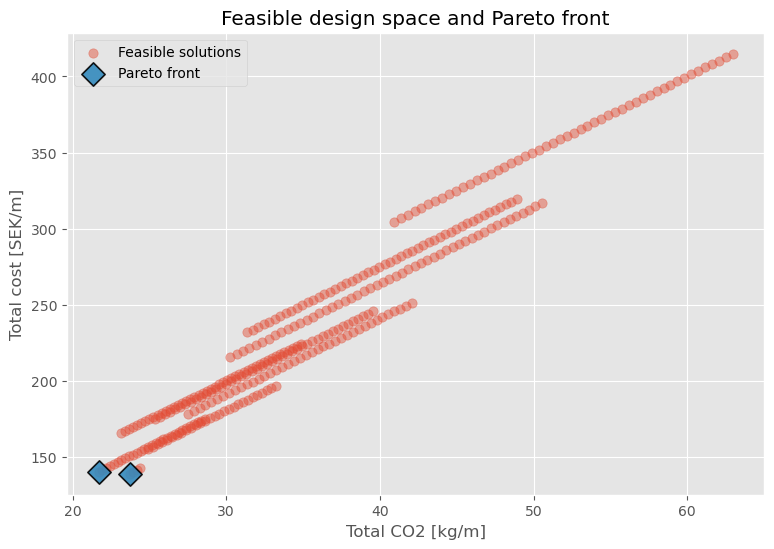

,b [mm],h [mm],As [mm2],M_Rd [kNm],Total CO2 [kg/m],Total cost [SEK/m],Constraint violation,Feasible,Objective 1 - CO2,Objective 2 - Cost,Penalized CO2,Penalized Cost,Dominated
0,135.0,328.571429,628.318531,76.868976,21.692054,140.520221,0.0,True,21.692054,140.520221,21.692054,140.520221,False
1,127.0,481.632653,402.123860,76.450253,23.716547,139.101105,0.0,True,23.716547,139.101105,23.716547,139.101105,False


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 35 — Identify Pareto-optimal feasible solutions
# ============================================================

# Use the evaluated population from Step 34
df = evaluated_population.copy()

# Keep only feasible solutions
feasible_df = df[df["Feasible"]].copy()

print(f"Total solutions: {len(df)}")
print(f"Feasible solutions: {len(feasible_df)}")

if feasible_df.empty:
    raise ValueError("No feasible solutions found. Check the design moment or the sectional_capacity data.")

# ------------------------------------------------------------
# Pareto dominance check
# ------------------------------------------------------------
objective_cols = ["Objective 1 - CO2", "Objective 2 - Cost"]

def is_dominated(row, df, obj_cols):
    for _, other in df.iterrows():
        no_worse = all(other[col] <= row[col] for col in obj_cols)
        strictly_better = any(other[col] < row[col] for col in obj_cols)

        if no_worse and strictly_better:
            return True
    return False

# Mark dominated and Pareto-optimal rows
feasible_df["Dominated"] = feasible_df.apply(
    lambda row: is_dominated(row, feasible_df, objective_cols),
    axis=1
)

pareto_front_df = feasible_df[~feasible_df["Dominated"]].copy()

print(f"Pareto-optimal feasible solutions: {len(pareto_front_df)}")

# ------------------------------------------------------------
# Plot feasible design space and Pareto front
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

plt.scatter(
    feasible_df["Objective 1 - CO2"],
    feasible_df["Objective 2 - Cost"],
    s=45,
    alpha=0.45,
    label="Feasible solutions"
)

plt.scatter(
    pareto_front_df["Objective 1 - CO2"],
    pareto_front_df["Objective 2 - Cost"],
    s=140,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    alpha=0.9,
    label="Pareto front"
)

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Feasible design space and Pareto front")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Show the Pareto front table
# ------------------------------------------------------------
pareto_front_df = pareto_front_df.sort_values(
    by=["Objective 1 - CO2", "Objective 2 - Cost"]
).reset_index(drop=True)

display(pareto_front_df)

In [46]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 36 — Parent selection, crossover, mutation, and repair
# ============================================================

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
offspring_target = 20        # number of valid children to generate
mutation_rate = 0.20         # probability of mutating each gene
random_seed = 42

rng = np.random.default_rng(random_seed)

# ------------------------------------------------------------
# Automatically detect design-variable columns
# Keep only columns shared with sectional_capacity and remove
# evaluation/output columns
# ------------------------------------------------------------
exclude_cols = {
    "Loading class",
    "Design moment [kNm]",
    "Moment resistance [kNm]",
    "Total CO2 [kg/m]",
    "Total cost [SEK/m]",
    "Objective 1 - CO2",
    "Objective 2 - Cost",
    "Feasible",
    "Dominated"
}

design_var_cols = [
    col for col in pareto_front_df.columns
    if col in sectional_capacity.columns and col not in exclude_cols
]

print("Detected design variables:")
print(design_var_cols)

if len(design_var_cols) == 0:
    raise ValueError("No design-variable columns were detected automatically.")

# ------------------------------------------------------------
# Parent pool
# Use Pareto-optimal feasible solutions as parents
# ------------------------------------------------------------
parent_pool = pareto_front_df[design_var_cols].drop_duplicates().reset_index(drop=True)

if len(parent_pool) < 2:
    raise ValueError("Need at least two parent solutions to generate offspring.")

print(f"Parent pool size: {len(parent_pool)}")

# ------------------------------------------------------------
# Gene domains from the real database
# Each variable can only take values that actually exist in the
# sectional_capacity dataset
# ------------------------------------------------------------
gene_domains = {
    col: sorted(sectional_capacity[col].dropna().unique().tolist())
    for col in design_var_cols
}

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def select_parents(pool_df):
    """Randomly choose two different parents."""
    idx = rng.choice(len(pool_df), size=2, replace=False)
    return pool_df.iloc[idx[0]], pool_df.iloc[idx[1]]

def crossover(parent1, parent2, cols):
    """Uniform crossover."""
    child = {}
    for col in cols:
        child[col] = parent1[col] if rng.random() < 0.5 else parent2[col]
    return child

def mutate(child, cols, mutation_rate, gene_domains):
    """Mutate genes using valid values from the database."""
    child = child.copy()
    for col in cols:
        if rng.random() < mutation_rate:
            child[col] = rng.choice(gene_domains[col])
    return child

def repair_to_real_section(child_dict, database_df, cols):
    """
    Keep the child only if it exactly exists in the real database.
    Returns matching row(s) from sectional_capacity.
    """
    child_df = pd.DataFrame([child_dict])
    merged = child_df.merge(database_df, on=cols, how="inner")
    return merged

# ------------------------------------------------------------
# Generate offspring
# ------------------------------------------------------------
valid_offspring = []
attempts = 0
max_attempts = 1000

while len(valid_offspring) < offspring_target and attempts < max_attempts:
    attempts += 1

    # 1. Select parents
    p1, p2 = select_parents(parent_pool)

    # 2. Crossover
    child = crossover(p1, p2, design_var_cols)

    # 3. Mutation
    child = mutate(child, design_var_cols, mutation_rate, gene_domains)

    # 4. Keep only children that exist in the real database
    repaired = repair_to_real_section(child, sectional_capacity, design_var_cols)

    if not repaired.empty:
        valid_offspring.append(repaired.iloc[0][design_var_cols].to_dict())

# ------------------------------------------------------------
# Store offspring population
# ------------------------------------------------------------
offspring_df = pd.DataFrame(valid_offspring).drop_duplicates().reset_index(drop=True)

print(f"Attempts made: {attempts}")
print(f"Valid offspring generated: {len(offspring_df)}")

display(offspring_df)

Detected design variables:
['b [mm]', 'h [mm]', 'As [mm2]', 'M_Rd [kNm]']
Parent pool size: 2
Attempts made: 357
Valid offspring generated: 2


,b [mm],h [mm],As [mm2],M_Rd [kNm]
0,135.0,328.571429,628.318531,76.868976
1,127.0,481.632653,402.123860,76.450253


In [52]:
# ============================================================
# STEP 37 — Evaluate offspring
# ============================================================

# Remove old evaluation columns if they already exist
cols_to_remove = [
    "Feasible",
    "Dominated",
    "Objective 1 - CO2",
    "Objective 2 - Cost"
]

offspring_clean = offspring_df.drop(columns=cols_to_remove, errors="ignore").copy()

# Merge with sectional capacity results
evaluated_offspring = offspring_clean.merge(
    sectional_capacity,
    on=design_var_cols,
    how="left"
)

# Feasibility check
evaluated_offspring["Feasible"] = (
    evaluated_offspring["M_Rd [kNm]"] >= evaluated_offspring["M_Ed,mid [kNm]"]
)

# Objectives
evaluated_offspring["Objective 1 - CO2"] = evaluated_offspring["Total CO2 [kg/m]"]
evaluated_offspring["Objective 2 - Cost"] = evaluated_offspring["Total cost [SEK/m]"]

display(evaluated_offspring.head())

,b [mm],h [mm],As [mm2],M_Rd [kNm],Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,...,Stirrups CO2 [kg/m],Total steel mass [kg/m],Total cost [SEK/m],Total CO2 [kg/m],Self weight [kN/m],"M_Ed,mid [kNm]",V_Ed [kN],Feasible,Objective 1 - CO2,Objective 2 - Cost
0,135.0,328.571429,628.318531,76.868976,2,1,25,,20,,...,0.0,4.932300,140.520221,21.692054,1.108929,76.247545,51.663393,True,21.692054,140.520221
1,127.0,481.632653,402.123860,76.450253,1,1,25,,16,,...,0.0,3.156672,139.101105,23.716547,1.529184,76.720332,52.293776,False,23.716547,139.101105


In [54]:
# ============================================================
# STEP 38 — Combine parent and offspring and form next generation
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Combine current population and evaluated offspring
# ------------------------------------------------------------
combined_population = pd.concat(
    [evaluated_population, evaluated_offspring],
    ignore_index=True
).copy()

# Remove duplicate designs if design variables are known
if "design_var_cols" in globals():
    combined_population = combined_population.drop_duplicates(
        subset=design_var_cols
    ).reset_index(drop=True)
else:
    combined_population = combined_population.drop_duplicates().reset_index(drop=True)

print(f"Combined population size: {len(combined_population)}")

# ------------------------------------------------------------
# 2. Keep only feasible solutions for Pareto ranking
# ------------------------------------------------------------
feasible_combined = combined_population[
    combined_population["Feasible"] == True
].copy().reset_index(drop=True)

print(f"Feasible combined solutions: {len(feasible_combined)}")

# ------------------------------------------------------------
# 3. Recompute domination in the combined population
# ------------------------------------------------------------
obj1 = "Objective 1 - CO2"
obj2 = "Objective 2 - Cost"

def is_dominated(row, df, obj1, obj2):
    """
    A row is dominated if another solution is:
    - no worse in both objectives
    - strictly better in at least one objective
    """
    others = df.drop(index=row.name)

    dominating_mask = (
        (others[obj1] <= row[obj1]) &
        (others[obj2] <= row[obj2]) &
        (
            (others[obj1] < row[obj1]) |
            (others[obj2] < row[obj2])
        )
    )

    return dominating_mask.any()

feasible_combined["Dominated"] = feasible_combined.apply(
    lambda row: is_dominated(row, feasible_combined, obj1, obj2),
    axis=1
)

# ------------------------------------------------------------
# 4. Extract next Pareto front
# ------------------------------------------------------------
pareto_front_df = feasible_combined[
    feasible_combined["Dominated"] == False
].copy().reset_index(drop=True)

print(f"Next-generation Pareto front size: {len(pareto_front_df)}")

# ------------------------------------------------------------
# 5. Define next generation population
# For now: use Pareto front directly
# ------------------------------------------------------------
next_generation_df = pareto_front_df.copy()

display_cols = []
if "design_var_cols" in globals():
    display_cols += design_var_cols

for col in [
    "M_Ed,mid [kNm]",
    "M_Rd [kNm]",
    "Objective 1 - CO2",
    "Objective 2 - Cost"
]:
    if col in next_generation_df.columns:
        display_cols.append(col)

display(next_generation_df[display_cols])

Combined population size: 450
Feasible combined solutions: 339
Next-generation Pareto front size: 2


,b [mm],h [mm],As [mm2],M_Rd [kNm],"M_Ed,mid [kNm]",M_Rd [kNm],Objective 1 - CO2,Objective 2 - Cost
0,127.0,481.632653,402.123860,76.450253,NaN,76.450253,23.716547,139.101105
1,135.0,328.571429,628.318531,76.868976,NaN,76.868976,21.692054,140.520221


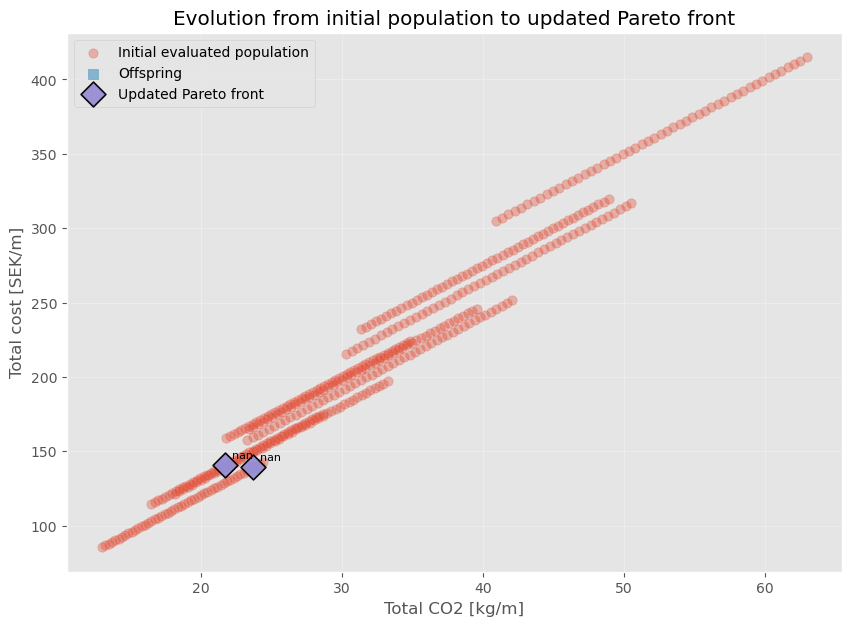

In [55]:
# ============================================================
# STEP 39 — Plot current population, offspring, and Pareto front
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# ------------------------------------------------------------
# 1. Plot original evaluated population
# ------------------------------------------------------------
plt.scatter(
    evaluated_population["Objective 1 - CO2"],
    evaluated_population["Objective 2 - Cost"],
    s=45,
    alpha=0.35,
    label="Initial evaluated population"
)

# ------------------------------------------------------------
# 2. Plot offspring
# ------------------------------------------------------------
plt.scatter(
    evaluated_offspring["Objective 1 - CO2"],
    evaluated_offspring["Objective 2 - Cost"],
    s=60,
    alpha=0.55,
    marker="s",
    label="Offspring"
)

# ------------------------------------------------------------
# 3. Plot updated Pareto front
# ------------------------------------------------------------
plt.scatter(
    pareto_front_df["Objective 1 - CO2"],
    pareto_front_df["Objective 2 - Cost"],
    s=160,
    alpha=0.95,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    label="Updated Pareto front"
)

# ------------------------------------------------------------
# 4. Add labels for Pareto solutions
# ------------------------------------------------------------
label_col = None
for candidate in ["Section ID", "Combination name"]:
    if candidate in pareto_front_df.columns:
        label_col = candidate
        break

if label_col is not None:
    for _, row in pareto_front_df.iterrows():
        plt.annotate(
            str(row[label_col]),
            (row["Objective 1 - CO2"], row["Objective 2 - Cost"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

# ------------------------------------------------------------
# 5. Final formatting
# ------------------------------------------------------------
plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Evolution from initial population to updated Pareto front")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [56]:
# ============================================================
# STEP 40 — Prepare next generation for another iteration
# ============================================================

# Keep only the design variables for the next generation
parent_population_df = next_generation_df[design_var_cols].drop_duplicates().reset_index(drop=True)

print(f"Next parent population size: {len(parent_population_df)}")
display(parent_population_df.head())

Next parent population size: 2


,b [mm],h [mm],As [mm2],M_Rd [kNm]
0,127.0,481.632653,402.123860,76.450253
1,135.0,328.571429,628.318531,76.868976


Generation 1
  Attempts made: 376
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 2
  Attempts made: 394
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 3
  Attempts made: 231
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 4
  Attempts made: 319
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 5
  Attempts made: 403
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 6
  Attempts made: 318
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 7
  Attempts made: 379
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 8
  Attempts made: 439
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
Generation 9
  Attempts made: 289
  Valid offspring: 2
  Feasible combined solutions: 2
  Pareto front size: 2
G

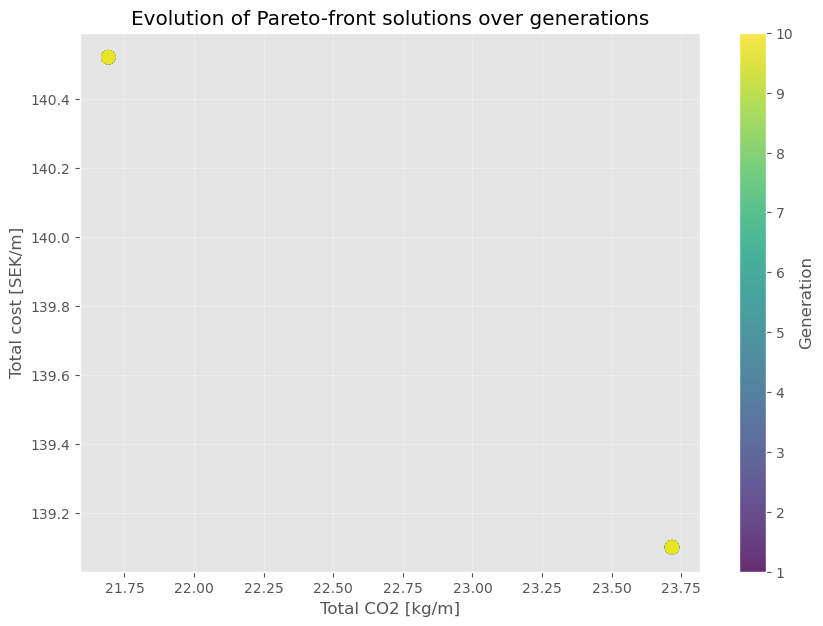

,b [mm],h [mm],As [mm2],M_Rd [kNm],Total CO2 [kg/m],Total cost [SEK/m],Constraint violation,Feasible,Objective 1 - CO2,Objective 2 - Cost,...,Long steel CO2 [kg/m],Stirrups mass [kg/m],Stirrups cost [SEK/m],Stirrups CO2 [kg/m],Total steel mass [kg/m],Self weight [kN/m],"M_Ed,mid [kNm]",V_Ed [kN],Dominated,Generation
0,127.0,481.632653,402.123860,76.450253,23.716547,139.101105,0.0,True,23.716547,139.101105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,10
1,135.0,328.571429,628.318531,76.868976,21.692054,140.520221,0.0,True,21.692054,140.520221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,10


In [57]:
# ============================================================
# STEP 40 — Run several generations automatically
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
n_generations = 10
offspring_target = 20
mutation_rate = 0.20
random_seed = 42

rng = np.random.default_rng(random_seed)

# ------------------------------------------------------------
# Use the same design variables as before
# ------------------------------------------------------------
if "design_var_cols" not in globals():
    raise ValueError("design_var_cols is not defined. Run Step 36 first.")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def select_parents(pool_df):
    idx = rng.choice(len(pool_df), size=2, replace=False)
    return pool_df.iloc[idx[0]], pool_df.iloc[idx[1]]

def crossover(parent1, parent2, cols):
    child = {}
    for col in cols:
        child[col] = parent1[col] if rng.random() < 0.5 else parent2[col]
    return child

def mutate(child, cols, mutation_rate, gene_domains):
    child = child.copy()
    for col in cols:
        if rng.random() < mutation_rate:
            child[col] = rng.choice(gene_domains[col])
    return child

def repair_to_real_section(child_dict, database_df, cols):
    child_df = pd.DataFrame([child_dict])
    merged = child_df.merge(database_df, on=cols, how="inner")
    return merged

def is_dominated(row, df, obj1, obj2):
    others = df.drop(index=row.name)
    dominating_mask = (
        (others[obj1] <= row[obj1]) &
        (others[obj2] <= row[obj2]) &
        (
            (others[obj1] < row[obj1]) |
            (others[obj2] < row[obj2])
        )
    )
    return dominating_mask.any()

# ------------------------------------------------------------
# Gene domains from the real database
# ------------------------------------------------------------
gene_domains = {
    col: sorted(sectional_capacity[col].dropna().unique().tolist())
    for col in design_var_cols
}

# ------------------------------------------------------------
# Start from current Pareto front
# ------------------------------------------------------------
current_parent_pool = pareto_front_df.copy()

history = []

for generation in range(1, n_generations + 1):
    print(f"Generation {generation}")

    # ----------------------------------------
    # 1. Build parent pool
    # ----------------------------------------
    parent_pool = current_parent_pool[design_var_cols].drop_duplicates().reset_index(drop=True)

    if len(parent_pool) < 2:
        print("Not enough parent solutions to continue.")
        break

    # ----------------------------------------
    # 2. Generate valid offspring
    # ----------------------------------------
    valid_offspring = []
    attempts = 0
    max_attempts = 2000

    while len(valid_offspring) < offspring_target and attempts < max_attempts:
        attempts += 1

        p1, p2 = select_parents(parent_pool)
        child = crossover(p1, p2, design_var_cols)
        child = mutate(child, design_var_cols, mutation_rate, gene_domains)

        repaired = repair_to_real_section(child, sectional_capacity, design_var_cols)

        if not repaired.empty:
            valid_offspring.append(repaired.iloc[0][design_var_cols].to_dict())

    offspring_df = pd.DataFrame(valid_offspring).drop_duplicates().reset_index(drop=True)

    print(f"  Attempts made: {attempts}")
    print(f"  Valid offspring: {len(offspring_df)}")

    if offspring_df.empty:
        print("No valid offspring could be generated.")
        break

    # ----------------------------------------
    # 3. Evaluate offspring using real columns
    # ----------------------------------------
    cols_to_remove = [
        "Feasible",
        "Dominated",
        "Objective 1 - CO2",
        "Objective 2 - Cost"
    ]

    offspring_clean = offspring_df.drop(columns=cols_to_remove, errors="ignore").copy()

    evaluated_offspring = offspring_clean.merge(
        sectional_capacity,
        on=design_var_cols,
        how="left"
    )

    evaluated_offspring["Feasible"] = (
        evaluated_offspring["M_Rd [kNm]"] >= evaluated_offspring["M_Ed,mid [kNm]"]
    )

    evaluated_offspring["Objective 1 - CO2"] = evaluated_offspring["Total CO2 [kg/m]"]
    evaluated_offspring["Objective 2 - Cost"] = evaluated_offspring["Total cost [SEK/m]"]

    # ----------------------------------------
    # 4. Combine parent population and offspring
    # ----------------------------------------
    combined_population = pd.concat(
        [current_parent_pool, evaluated_offspring],
        ignore_index=True
    ).copy()

    combined_population = combined_population.drop_duplicates(
        subset=design_var_cols
    ).reset_index(drop=True)

    feasible_combined = combined_population[
        combined_population["Feasible"] == True
    ].copy().reset_index(drop=True)

    if feasible_combined.empty:
        print("No feasible solutions in combined population.")
        break

    # ----------------------------------------
    # 5. Compute Pareto front
    # ----------------------------------------
    obj1 = "Objective 1 - CO2"
    obj2 = "Objective 2 - Cost"

    feasible_combined["Dominated"] = feasible_combined.apply(
        lambda row: is_dominated(row, feasible_combined, obj1, obj2),
        axis=1
    )

    pareto_front_df = feasible_combined[
        feasible_combined["Dominated"] == False
    ].copy().reset_index(drop=True)

    pareto_front_df["Generation"] = generation
    history.append(pareto_front_df.copy())

    print(f"  Feasible combined solutions: {len(feasible_combined)}")
    print(f"  Pareto front size: {len(pareto_front_df)}")

    # ----------------------------------------
    # 6. Update parent pool for next generation
    # ----------------------------------------
    current_parent_pool = pareto_front_df.copy()

# ------------------------------------------------------------
# Combine history for plotting
# ------------------------------------------------------------
if len(history) == 0:
    raise ValueError("No generation history was created.")

history_df = pd.concat(history, ignore_index=True)

# ------------------------------------------------------------
# Plot evolution of Pareto fronts
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    history_df["Objective 1 - CO2"],
    history_df["Objective 2 - Cost"],
    c=history_df["Generation"],
    s=100,
    alpha=0.8
)

plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total cost [SEK/m]")
plt.title("Evolution of Pareto-front solutions over generations")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Generation")
plt.show()

# ------------------------------------------------------------
# Final Pareto front
# ------------------------------------------------------------
final_pareto_front = current_parent_pool.copy()

display(final_pareto_front)